# Customer Segmentation Using Unsupervised Learning

## Objective
Cluster customers based on spending habits and propose marketing strategies tailored to each segment.

## Dataset
Mall Customers Dataset

## Instructions
- Conduct Exploratory Data Analysis (EDA)
- Apply K-Means Clustering to segment customers
- Use PCA or t-SNE to visualize the clusters
- Suggest relevant marketing strategies for each identified segment

In [13]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# For nicer plots
sns.set(style="whitegrid")

## 1. Load Dataset

In [14]:
# Load the dataset
df = pd.read_csv("Mall_Customers.csv")  # replace with your path

# Display first 5 rows
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Exploratory Data Analysis (EDA)

In [15]:
# Basic info
df.info()

# Check for null values
df.isnull().sum()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


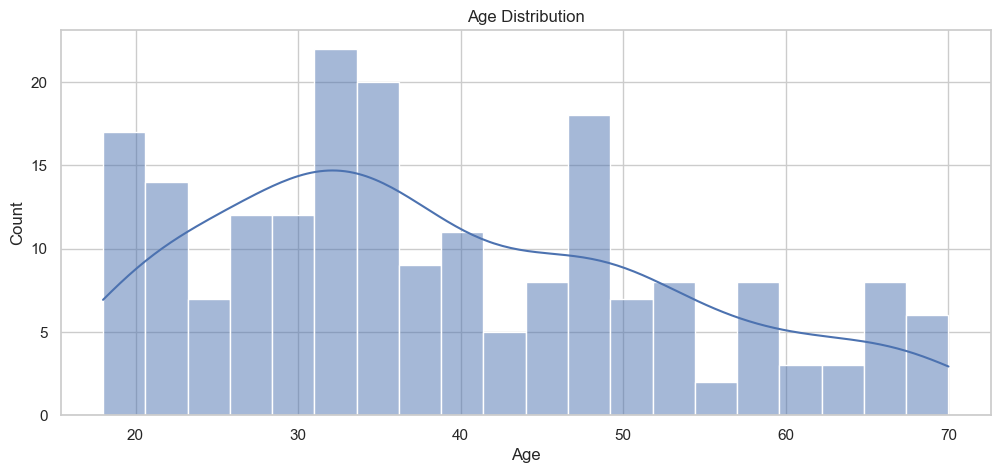

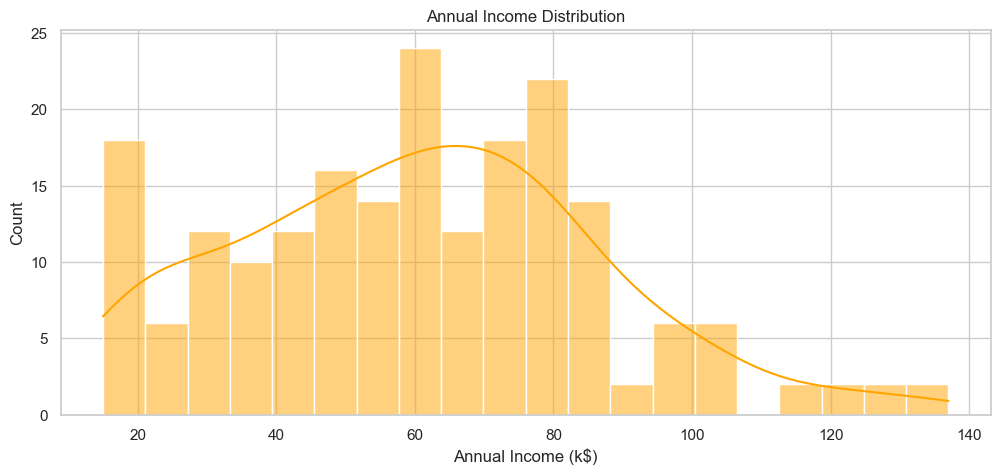

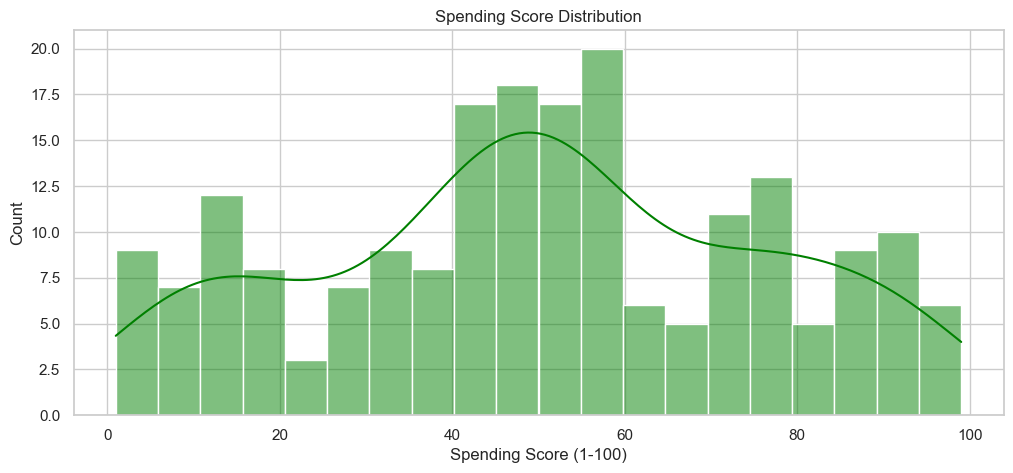

In [16]:
# Distribution of numerical features
plt.figure(figsize=(12,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, color='orange')
plt.title("Annual Income Distribution")
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, color='green')
plt.title("Spending Score Distribution")
plt.show()

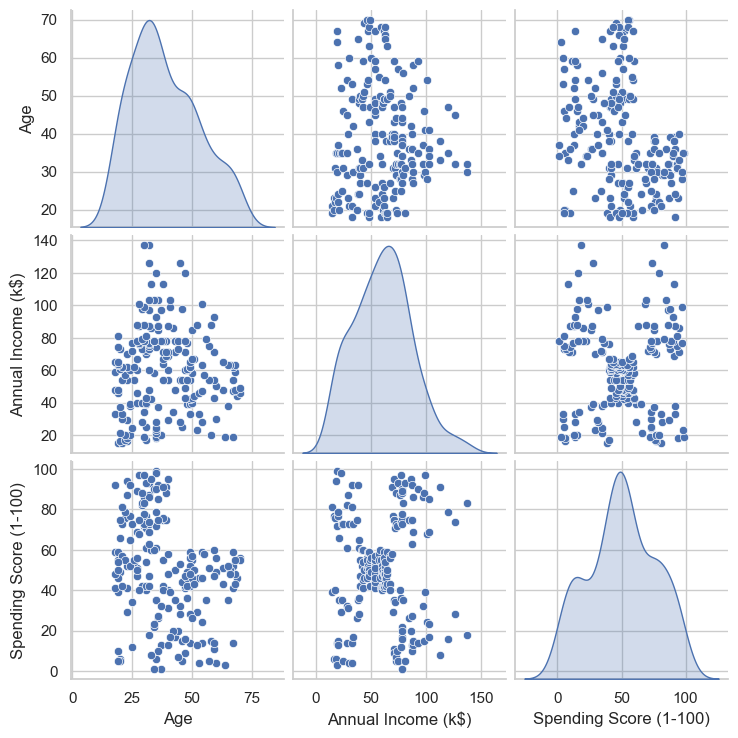

In [17]:
# Pairplot to see relationships
sns.pairplot(df[['Age','Annual Income (k$)','Spending Score (1-100)']], diag_kind='kde')
plt.show()

## 3. Data Preprocessing

In [18]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. K-Means Clustering

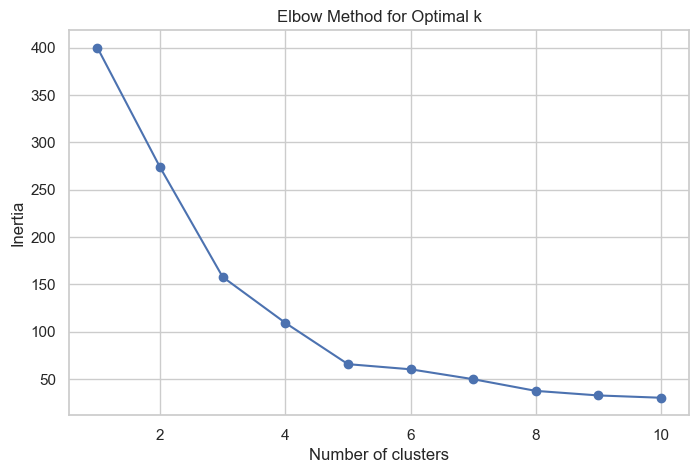

In [19]:
# Find the optimal number of clusters using the Elbow Method
import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")
inertia = []
K = range(1,11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [20]:
# Apply KMeans with chosen number of clusters (e.g., k=5)
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['Cluster'] = y_kmeans

## 5. Cluster Visualization

### 5.1 Using PCA

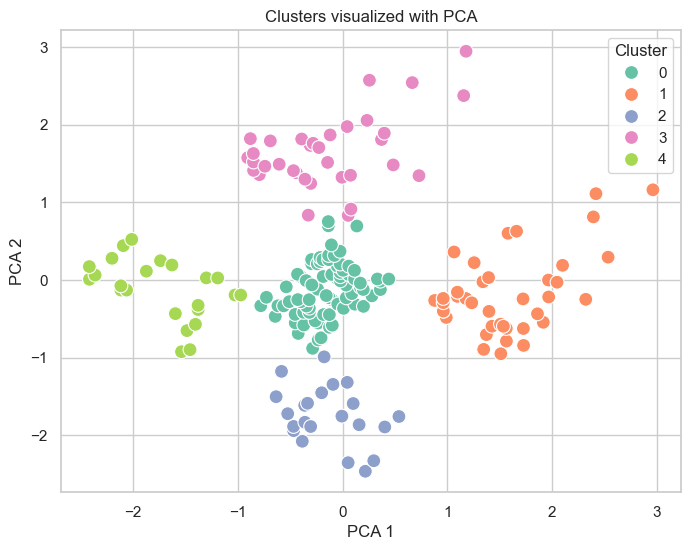

In [21]:
# Reduce dimensions using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['Cluster'], palette='Set2', s=100)
plt.title("Clusters visualized with PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.show()

### 5.2 Using t-SNE (optional)

In [ ]:
# Reduce dimensions using t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df['Cluster'], palette='Set2', s=100)
plt.title("Clusters visualized with t-SNE")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster")
plt.show()

## 6. Cluster Analysis & Marketing Strategy

- **Cluster 0:** Low income, low spending → Target with discount offers and loyalty programs.
- **Cluster 1:** High income, high spending → Premium products, exclusive memberships.
- **Cluster 2:** Average income, high spending → Upselling & cross-selling strategies.
- **Cluster 3:** Low income, high spending → Budget-conscious deals & bundles.
- **Cluster 4:** High income, low spending → Encourage brand engagement and awareness campaigns.

> These strategies can be customized further based on more customer data and behavioral insights.